# Notebook 03 — Yield Curve Reconstruction

## Objective

This notebook reconstructs the full U.S. Treasury yield curve from a single
observable input — the **3-month (short-rate) yield** — using a
**Hybrid Empirical-CIR** framework.

The approach combines:
- the **observed short rate** $r_t$ as the primary driver of level, and
- **CIR term-structure shape information** — specifically the loading factor
  $B(\tau)$ and the CIR-implied spread — as auxiliary maturity-shaping features.

One `LinearRegression` model is fitted per target maturity
(6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y).  Each model predicts the
**spread** $y(t,\tau) - r_t$; the final yield estimate is:

$$\hat{y}(t, \tau) = r_t + \hat{\text{spread}}(t, \tau)$$

## Relation to CIR Calibration (Notebook 02)

Notebook 02 calibrated the CIR parameters
$(\alpha, \kappa, \theta, \sigma)$ via nonlinear least-squares.
A severe $\kappa$–$\theta$ identification ridge was detected:
$\kappa = 0.001$ is near-zero, driving $\theta = 2.41$ to an
economically implausible level.  Only the composite $\alpha = \kappa\theta$
is reliably identified.

**Consequence for this notebook:** $\theta$ is never used directly as a
regression feature.  CIR quantities appear only as term-structure shape
proxies (spread, loading factor).

Notebook 04 will evaluate the reconstruction on the held-out test set.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
from __future__ import annotations
import logging
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Union

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Machine learning ──────────────────────────────────────────────────────────
import joblib
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Configuration ─────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# Plotting style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Reproducibility
np.random.seed(42)

print("Environment ready.")

Environment ready.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  UTILITY FUNCTIONS                                                           ║
# ║  Embedded here so the notebook is self-contained for Google Colab.           ║
# ║  Logic is identical to src/yield_curve.py.                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Constants ─────────────────────────────────────────────────────────────────

MATURITY_MAP: Dict[str, float] = {
    "3M": 0.25,  "6M": 0.50,  "9M": 0.75,
    "1Y": 1.00,  "2Y": 2.00,  "5Y": 5.00,
    "10Y": 10.00, "20Y": 20.00, "30Y": 30.00,
}

SHORT_RATE_MATURITY: str = "3M"
RECONSTRUCTION_MATURITIES: tuple[str, ...] = (
    "6M", "9M", "1Y", "2Y", "5Y", "10Y", "20Y", "30Y"
)
SPREAD_ANCHOR_TAU: float = 0.25   # 3-month anchor for CIR spread
_GAMMA_MIN: float = 1e-12          # numerical floor


# ── Section 1: Maturity utilities ─────────────────────────────────────────────

def maturity_to_years(maturity: str) -> float:
    """Convert a maturity label string to years.

    Parameters
    ----------
    maturity : str
        Label such as '3M', '1Y', '10Y'.

    Returns
    -------
    float
        Equivalent number of years.

    Raises
    ------
    KeyError
        If *maturity* is not recognised.
    """
    if maturity not in MATURITY_MAP:
        raise KeyError(
            f"Unknown maturity label '{maturity}'. "
            f"Recognised labels: {sorted(MATURITY_MAP)}"
        )
    return MATURITY_MAP[maturity]


# ── Section 2: CIR term-structure functions ───────────────────────────────────

def cir_gamma(kappa: float, sigma: float) -> float:
    """Compute the CIR auxiliary parameter γ = sqrt(κ² + 2σ²).

    A minimum floor _GAMMA_MIN is applied to prevent downstream
    division-by-zero for near-zero parameter values.

    Parameters
    ----------
    kappa : float
        Mean-reversion speed (κ > 0).
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        γ = max(sqrt(κ² + 2σ²), _GAMMA_MIN).

    Raises
    ------
    ValueError
        If kappa or sigma are not strictly positive.
    """
    if kappa <= 0:
        raise ValueError(f"kappa must be positive, got {kappa}.")
    if sigma <= 0:
        raise ValueError(f"sigma must be positive, got {sigma}.")
    gamma = float(np.sqrt(kappa ** 2 + 2.0 * sigma ** 2))
    if gamma < _GAMMA_MIN:
        logger.warning("gamma = %.3e below floor; clamping.", gamma)
        gamma = _GAMMA_MIN
    return gamma


def cir_B(tau: float, kappa: float, sigma: float) -> float:
    """Compute the CIR bond-loading factor B(τ).

    Standard formula:

        B(τ) = 2(e^{γτ} − 1) / [(γ + κ)(e^{γτ} − 1) + 2γ]

    Taylor approximation B(τ) ≈ τ / [1 + (κ/2)τ] is used when γτ < 1e-6
    to avoid catastrophic cancellation (relevant when κ = 0.001).

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    kappa : float
        Mean-reversion speed (κ > 0).
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        B(τ) ≥ 0.

    Raises
    ------
    ValueError
        If tau ≤ 0.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    gamma = cir_gamma(kappa, sigma)
    gamma_tau = gamma * tau
    if gamma_tau < 1e-6:
        return float(tau / (1.0 + 0.5 * kappa * tau))
    exp_gt = np.exp(gamma_tau)
    numerator   = 2.0 * (exp_gt - 1.0)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    if abs(denominator) < _GAMMA_MIN:
        logger.warning("Near-zero denominator in cir_B (tau=%.4f).", tau)
        return 0.0
    return float(numerator / denominator)


def cir_log_A(tau: float, kappa: float, theta: float, sigma: float) -> float:
    """Compute log A(τ) in the CIR bond-pricing formula.

    Standard expression (computed in log-space to avoid overflow):

        log A(τ) = (2α/σ²) · [log(2γ) + (γ+κ)τ/2 − log(denominator)]

    where α = κθ and denominator = (γ+κ)(e^{γτ}−1) + 2γ.

    Taylor fallback is used when γτ < 1e-6.

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    kappa : float
        Mean-reversion speed (κ > 0).
    theta : float
        Long-run mean of the short rate.
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        log A(τ) (may be negative for long maturities).

    Raises
    ------
    ValueError
        If tau ≤ 0, sigma ≤ 0, or denominator is non-positive.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    if sigma <= 0:
        raise ValueError(f"sigma must be positive, got {sigma}.")
    alpha = kappa * theta
    gamma = cir_gamma(kappa, sigma)
    gamma_tau = gamma * tau
    two_alpha_over_sigma2 = 2.0 * alpha / sigma ** 2
    if gamma_tau < 1e-6:
        half_sum_tau = 0.5 * (gamma + kappa) * tau
        log_ratio = half_sum_tau - np.log1p(half_sum_tau)
        return float(two_alpha_over_sigma2 * log_ratio)
    exp_gt = np.exp(gamma_tau)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    if denominator <= 0.0:
        raise ValueError(
            f"Non-positive denominator in cir_log_A: {denominator:.6e} "
            f"(tau={tau}, kappa={kappa}, sigma={sigma})."
        )
    log_arg = (
        np.log(2.0 * gamma)
        + 0.5 * (gamma + kappa) * tau
        - np.log(denominator)
    )
    return float(two_alpha_over_sigma2 * log_arg)


def cir_yield(
    tau: float,
    r_t: float,
    kappa: float,
    theta: float,
    sigma: float,
) -> float:
    """Compute the CIR model-implied continuously-compounded yield.

        y_CIR(t, τ) = [B(τ)·r_t − log A(τ)] / τ

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    r_t : float
        Observed short rate (decimal).
    kappa, theta, sigma : float
        CIR parameters.

    Returns
    -------
    float
        CIR-implied yield in decimal form.

    Raises
    ------
    ValueError
        If tau ≤ 0.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    B      = cir_B(tau, kappa, sigma)
    log_A  = cir_log_A(tau, kappa, theta, sigma)
    return float((B * r_t - log_A) / tau)


# ── Section 3: CIR parameter handling ────────────────────────────────────────

@dataclass(frozen=True)
class CIRParameters:
    """Immutable container for calibrated CIR model parameters.

    Attributes
    ----------
    alpha : float
        Drift product α = κ × θ.  The reliably identified composite.
    kappa : float
        Mean-reversion speed κ (weakly identified individually).
    theta : float
        Long-run mean θ (weakly identified; used only internally in log_A).
    sigma : float
        Volatility coefficient σ.
    """
    alpha: float
    kappa: float
    theta: float
    sigma: float

    def __post_init__(self) -> None:
        if self.kappa <= 0:
            raise ValueError(f"kappa must be positive, got {self.kappa}.")
        if self.sigma <= 0:
            raise ValueError(f"sigma must be positive, got {self.sigma}.")


def load_cir_parameters(
    path: Union[str, Path] = "results/cir_parameters.csv",
) -> CIRParameters:
    """Load calibrated CIR parameters from a row-wise CSV file.

    Expected format::

        parameter,value,description
        alpha,0.00240671785519546,Drift product alpha = kappa * theta
        kappa,0.001,Mean reversion speed
        theta,2.40671785519546,Long-run mean of short rate
        sigma,0.0469497250260536,Volatility coefficient

    Parameters
    ----------
    path : str or Path
        Path to the CIR parameters CSV.

    Returns
    -------
    CIRParameters

    Raises
    ------
    FileNotFoundError
        If the file does not exist.
    KeyError
        If required parameters are missing.
    ValueError
        If values cannot be cast to float.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"CIR parameter file not found: {path.resolve()}")
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    df["parameter"] = df["parameter"].str.strip().str.lower()
    required_cols = {"parameter", "value"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Parameter file missing columns: {missing}.")
    param_series = df.set_index("parameter")["value"]
    required_params = ["alpha", "kappa", "theta", "sigma"]
    missing_params  = [p for p in required_params if p not in param_series.index]
    if missing_params:
        raise KeyError(f"Missing parameters: {missing_params}.")
    try:
        params = {p: float(param_series[p]) for p in required_params}
    except (TypeError, ValueError) as exc:
        raise ValueError(f"Could not convert parameter values to float: {exc}") from exc
    return CIRParameters(**params)


# ── Section 4: Feature engineering ───────────────────────────────────────────

def compute_cir_features(
    short_rate_series: pd.Series,
    maturity: str,
    cir_parameters: CIRParameters,
    *,
    include_squared: bool = True,
) -> pd.DataFrame:
    """Construct CIR-based regression features for a single maturity.

    Features:

    1. ``short_rate``    — observed short rate r_t
    2. ``B_times_r``     — CIR loading factor B(τ) × r_t
    3. ``cir_spread``    — y_CIR(t, τ) − y_CIR(t, 0.25)
    4. ``short_rate_sq`` — r_t² (optional)

    Parameters
    ----------
    short_rate_series : pd.Series
        Observed 3M yields in decimal form.
    maturity : str
        Target maturity label (e.g. '10Y').
    cir_parameters : CIRParameters
        Calibrated CIR parameters.
    include_squared : bool
        Include r_t² feature.  Default True.

    Returns
    -------
    pd.DataFrame
        Feature matrix aligned to short_rate_series index.

    Raises
    ------
    ValueError
        If short_rate_series is empty.
    KeyError
        If maturity is unrecognised.
    """
    if short_rate_series.empty:
        raise ValueError("short_rate_series must not be empty.")
    tau   = maturity_to_years(maturity)
    kappa = cir_parameters.kappa
    theta = cir_parameters.theta
    sigma = cir_parameters.sigma
    B_tau    = cir_B(tau,              kappa, sigma)
    B_anchor = cir_B(SPREAD_ANCHOR_TAU, kappa, sigma)
    r = short_rate_series.to_numpy(dtype=float)
    log_A_tau    = cir_log_A(tau,               kappa, theta, sigma)
    log_A_anchor = cir_log_A(SPREAD_ANCHOR_TAU, kappa, theta, sigma)
    cir_yld    = (B_tau    * r - log_A_tau)    / tau
    cir_anchor = (B_anchor * r - log_A_anchor) / SPREAD_ANCHOR_TAU
    cir_spr    = cir_yld - cir_anchor
    data: Dict[str, np.ndarray] = {
        "short_rate": r,
        "B_times_r":  B_tau * r,
        "cir_spread": cir_spr,
    }


    # New regime-aware features

    data["r_momentum_30"] = (
        short_rate_series.diff(30)
        .bfill()
        .to_numpy()
    )

    data["r_momentum_90"] = (
        short_rate_series.diff(90)
        .bfill()
        .to_numpy()
    )

    data["r_vol_30"] = (
        short_rate_series.rolling(30)
        .std()
        .bfill()
        .to_numpy()
    )

    data["r_acceleration"] = (

    short_rate_series.diff(30)

    .diff(30)

    .bfill()

    .to_numpy()

    )

    data["r_vs_ma60"] = (
    short_rate_series
    - short_rate_series.rolling(60).mean()
).bfill().to_numpy()
    
    data["vol_regime"] = (
    short_rate_series.rolling(30).std() /
    short_rate_series.rolling(252).std()
).bfill().to_numpy()
    
    return pd.DataFrame(data, index=short_rate_series.index)


# ── Section 5: Dataset construction ──────────────────────────────────────────

def _prepare_training_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "Date" in df.columns:
        df = df.set_index("Date")
    try:
        df.index = pd.to_datetime(df.index)
    except Exception:
        pass
    return df


def build_reconstruction_dataset(
    training_dataframe: pd.DataFrame,
    cir_parameters: CIRParameters,
    *,
    include_squared: bool = True,
) -> Dict[str, Dict[str, Union[pd.DataFrame, pd.Series]]]:
    """Assemble per-maturity training matrices (spread formulation).

    Target variable:  spread = target_yield − short_rate.

    Parameters
    ----------
    training_dataframe : pd.DataFrame
        Cleaned training data with columns Date, 3M, 6M, … 30Y.
    cir_parameters : CIRParameters
        Calibrated CIR parameters.
    include_squared : bool
        Include r_t² feature.  Default True.

    Returns
    -------
    dict
        Keyed by maturity label; each value is {'X': DataFrame, 'y': Series}.

    Raises
    ------
    ValueError
        If training_dataframe is empty.
    KeyError
        If the 3M column is absent.
    """
    df = _prepare_training_dataframe(training_dataframe)
    if df.empty:
        raise ValueError("training_dataframe is empty after preprocessing.")
    if SHORT_RATE_MATURITY not in df.columns:
        raise KeyError(
            f"Short-rate column '{SHORT_RATE_MATURITY}' not found. "
            f"Columns: {list(df.columns)}"
        )
    short_rate_series = df[SHORT_RATE_MATURITY]
    datasets: Dict[str, Dict[str, Union[pd.DataFrame, pd.Series]]] = {}
    for mat in RECONSTRUCTION_MATURITIES:
        if mat not in df.columns:
            logger.warning("Maturity '%s' not in training data; skipping.", mat)
            continue
        spread = df[mat] - short_rate_series
        spread.name = f"spread_{mat}"
        X = compute_cir_features(
            short_rate_series, mat, cir_parameters,
            include_squared=include_squared,
        )
        # Momentum feature: lagged short rate captures rate-change dynamics
        X = X.copy()
        X["r_lag1"] = short_rate_series.shift(1).bfill()
        combined = pd.concat([X, spread], axis=1).dropna()
        datasets[mat] = {
            "X": combined[X.columns],
            "y": combined[spread.name],
        }
    return datasets


# ── Section 6: Model fitting ──────────────────────────────────────────────────

def fit_reconstruction_models(
    datasets: Dict[str, Dict[str, Union[pd.DataFrame, pd.Series]]]
) -> Dict[str, Dict]:
    """Fit one LinearRegression (or Ridge) model per maturity.

    Parameters
    ----------
    datasets : dict
        Output of build_reconstruction_dataset.

    Returns
    -------
    dict
        Keyed by maturity; each value is {'model': estimator,
        'feature_names': list[str]}.

    Raises
    ------
    ValueError
        If datasets is empty or a dataset is missing 'X'/'y' keys.
    """
    if not datasets:
        raise ValueError("datasets dict is empty; nothing to fit.")
    models: Dict[str, Dict] = {}
    for mat, data in datasets.items():
        if "X" not in data or "y" not in data:
            raise ValueError(f"Dataset for '{mat}' missing 'X' or 'y'.")
        X, y = data["X"], data["y"]
        if X.empty or y.empty:
            logger.warning("Empty dataset for '%s'; skipping.", mat)
            continue



        model = Pipeline([

    (

        "scaler",

        StandardScaler()

    ),

    (

        "poly",

        PolynomialFeatures(

            degree=2,

            include_bias=False

        )

    ),

    (

        "ridge",

        RidgeCV(

            alphas=[

                0.0001,

                0.001,

                0.01,

                0.1,

                1,

                10,

                100,

                1000

            ],

            cv=5

        )

    )

])
        
        print("\n" + "="*50)
        print(f"Maturity: {mat}")
        print(X.var().sort_values())

        model.fit(X.to_numpy(), y.to_numpy())
        y_pred_train = model.predict(X.to_numpy())
        phi = float((y.to_numpy() - y_pred_train).mean())

        print(
            f"{mat:>3s} | XGBoost | phi={phi:.6f}"
            )
        
        models[mat] = {
            "model": model,
            "feature_names": list(X.columns),
            "phi": phi,
            }
    return models


# ── Section 7: Yield reconstruction ──────────────────────────────────────────

def reconstruct_yield_curve(
    short_rate_series: pd.Series,
    models: Dict[str, Dict],
    cir_parameters: CIRParameters,
    *,
    include_squared: bool = True,
) -> pd.DataFrame:
    """Reconstruct the full yield curve from fitted per-maturity models.

        yield_hat(t, τ) = r_t + model.predict(X(t, τ))

    Parameters
    ----------
    short_rate_series : pd.Series
        Observed 3M short rates (decimal).
    models : dict
        Output of fit_reconstruction_models.
    cir_parameters : CIRParameters
        Calibrated CIR parameters.
    include_squared : bool
        Must match the flag used during training.  Default True.

    Returns
    -------
    pd.DataFrame
        One column per maturity, named 'yield_hat_<MAT>'.

    Raises
    ------
    ValueError
        If short_rate_series or models is empty.
    """
    if short_rate_series.empty:
        raise ValueError("short_rate_series must not be empty.")
    if not models:
        raise ValueError("models dict is empty; cannot reconstruct.")
    r = short_rate_series.to_numpy(dtype=float)
    result_frames: Dict[str, pd.Series] = {}
    for mat, model_info in models.items():
        model = model_info["model"]
        X = compute_cir_features(
            short_rate_series, mat, cir_parameters,
            include_squared=include_squared,
        )
        # Must match feature set used in build_reconstruction_dataset
        X = X.copy()
        X["r_lag1"] = short_rate_series.shift(1).bfill()
        
        predicted_spread = model.predict(X.to_numpy())
        phi = model_info.get("phi", 0.0)
        predicted_spread = predicted_spread + phi

        result_frames[f"yield_hat_{mat}"] = pd.Series(
            r + predicted_spread,
            index=short_rate_series.index,
            name=f"yield_hat_{mat}",
        )
    return pd.DataFrame(result_frames)


# ── Section 8: Export utilities ───────────────────────────────────────────────

def save_reconstructed_yields(
    reconstructed: pd.DataFrame,
    path: Union[str, Path] = "results/yield_curve_reconstruction.csv",
) -> Path:
    """Save reconstructed yields DataFrame to CSV.

    Parameters
    ----------
    reconstructed : pd.DataFrame
        Output of reconstruct_yield_curve.
    path : str or Path
        Output file path.  Parent directories created if absent.

    Returns
    -------
    Path
        Resolved path of saved file.

    Raises
    ------
    ValueError
        If reconstructed is empty.
    """
    if reconstructed.empty:
        raise ValueError("reconstructed DataFrame is empty; nothing to save.")
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    reconstructed.to_csv(path)
    print(f"Saved reconstructed yields → {path.resolve()}")
    return path.resolve()


def save_models(
    models: Dict[str, Dict],
    directory: Union[str, Path] = "results/models",
) -> Dict[str, Path]:
    """Persist fitted per-maturity models via joblib.

    Saves each model as <directory>/model_<maturity>.joblib.

    Parameters
    ----------
    models : dict
        Output of fit_reconstruction_models.
    directory : str or Path
        Output directory.  Created if absent.

    Returns
    -------
    dict
        Maturity label → resolved Path of saved file.

    Raises
    ------
    ValueError
        If models is empty.
    """
    if not models:
        raise ValueError("models dict is empty; nothing to save.")
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    saved: Dict[str, Path] = {}
    for mat, model_info in models.items():
        filename = directory / f"model_{mat}.joblib"
        joblib.dump(model_info, filename)
        saved[mat] = filename.resolve()
        print(f"  Saved model for {mat:>3s} → {filename}")
    return saved


print("All utility functions defined.")

All utility functions defined.


## 4. Load Data

Load the cleaned training dataset and the calibrated CIR parameters produced
by Notebooks 01 and 02 respectively.  No additional EDA is performed here —
refer to Notebook 01 for full exploratory analysis.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DATA_PATH = Path("../data/processed/cleaned_train.csv")
CIR_PARAMS_PATH = Path("../results/cir_parameters.csv")

# ── Load training data ────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_DATA_PATH, parse_dates=["Date"], index_col="Date")

print(f"Training data shape : {train_df.shape}")
print(f"Date range          : {train_df.index.min().date()} → {train_df.index.max().date()}")
print(f"Columns             : {list(train_df.columns)}")
print()
train_df.head(3)

Training data shape : (1976, 9)
Date range          : 2016-05-19 → 2024-04-26
Columns             : ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']



,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793


In [4]:
# ── Load CIR parameters ───────────────────────────────────────────────────────
cir_params = load_cir_parameters(CIR_PARAMS_PATH)

print("Loaded CIR Parameters")
print("─" * 40)
print(f"  alpha (κθ) : {cir_params.alpha:.8f}   ← reliably identified composite")
print(f"  kappa  (κ) : {cir_params.kappa:.8f}   ← weakly identified individually")
print(f"  theta  (θ) : {cir_params.theta:.8f}   ← unrealistic; artifact of κ–θ ridge")
print(f"  sigma  (σ) : {cir_params.sigma:.8f}")
print()
print("Note: theta is NOT used as a regression feature (see Methodology section).")

Loaded CIR Parameters
────────────────────────────────────────
  alpha (κθ) : 0.00240672   ← reliably identified composite
  kappa  (κ) : 0.00100000   ← weakly identified individually
  theta  (θ) : 2.40671820   ← unrealistic; artifact of κ–θ ridge
  sigma  (σ) : 0.04694972

Note: theta is NOT used as a regression feature (see Methodology section).


## 5. CIR Yield Curve Theory

### The CIR Short-Rate Process

Under the Cox–Ingersoll–Ross (1985) model the short rate follows:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

The square-root diffusion keeps $r_t \geq 0$ when the Feller condition
$2\kappa\theta \geq \sigma^2$ is satisfied.

### Zero-Coupon Bond Price

The time-$t$ price of a zero-coupon bond maturing at $t + \tau$ is:

$$P(t, \tau) = A(\tau)\,\exp\!\bigl(-B(\tau)\,r_t\bigr)$$

where the auxiliary parameter $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$ and:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}$$

$$\log A(\tau) = \frac{2\alpha}{\sigma^2}
    \left[\log(2\gamma) + \tfrac{1}{2}(\gamma+\kappa)\tau
           - \log\!\bigl((\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma\bigr)\right]$$

where $\alpha = \kappa\theta$.

### Continuously-Compounded Yield

$$y_{\text{CIR}}(t,\tau) = -\frac{\log P(t,\tau)}{\tau}
    = \frac{B(\tau)\,r_t - \log A(\tau)}{\tau}$$

### Numerical Stability Note

The calibrated $\kappa = 0.001$ is extremely small.  When $\gamma\tau < 10^{-6}$,
first-order Taylor expansions replace the standard formulae to prevent
catastrophic cancellation in $e^{\gamma\tau}-1$.

## 6. Methodology: Hybrid Empirical-CIR Reconstruction

### Why Pure CIR Was Rejected

A pure CIR reconstruction would set
$\hat{y}(t,\tau) = y_{\text{CIR}}(t,\tau)$ using the calibrated parameters.
This is unsuitable here because:

1. **$\kappa$–$\theta$ identification ridge.**  The likelihood surface
   is nearly flat along the $\kappa\theta = \text{const}$ manifold, so the
   individually calibrated $\kappa$ and $\theta$ are unreliable.  Specifically,
   $\theta = 2.41$ implies a long-run rate of 241 % — economically absurd.

2. **Pure CIR misprices the short end.**  With $\kappa \approx 0$, B(τ) ≈ τ
   and $\log A(\tau) \approx 0$, so $y_{\text{CIR}} \approx r_t$ for all τ —
   predicting a flat yield curve regardless of the term structure.

3. **No empirical residual correction.**  Real yield curves exhibit
   time-varying risk premia and liquidity effects that the CIR model ignores.

### Why Hybrid Empirical-CIR Was Selected

The hybrid approach uses:

| Feature | Role |
|---------|------|
| $r_t$ (observed 3M yield) | Level anchor — primary driver of all maturities |
| $B(\tau) \times r_t$ | Maturity-dependent CIR loading; encodes non-linearity in τ |
| CIR spread: $y_{\text{CIR}}(t,\tau) - y_{\text{CIR}}(t, 0.25)$ | Term-structure shape from CIR theory |
| $r_t^2$ | Captures convexity / non-linear regime effects |

**Target:** spread $= y(t,\tau) - r_t$

**Prediction:** $\hat{y}(t,\tau) = r_t + \hat{\text{spread}}(t,\tau)$

This formulation guarantees that by construction the reconstruction is
anchored at the observed short rate, and CIR quantities contribute only
incremental shape information — which is robust to the $\kappa$–$\theta$
identification problem.

In [5]:
# ── Build per-maturity training matrices ──────────────────────────────────────
datasets = build_reconstruction_dataset(train_df, cir_params, include_squared=True)

print(f"Reconstruction datasets built for {len(datasets)} maturities:")
for mat, data in datasets.items():
    print(f"  {mat:>3s}  →  X: {data['X'].shape}   y: {data['y'].shape}")

print()
print("Example feature matrix (10Y, first 5 rows):")
datasets["10Y"]["X"].head()

Reconstruction datasets built for 8 maturities:
   6M  →  X: (1976, 10)   y: (1976,)
   9M  →  X: (1976, 10)   y: (1976,)
   1Y  →  X: (1976, 10)   y: (1976,)
   2Y  →  X: (1976, 10)   y: (1976,)
   5Y  →  X: (1976, 10)   y: (1976,)
  10Y  →  X: (1976, 10)   y: (1976,)
  20Y  →  X: (1976, 10)   y: (1976,)
  30Y  →  X: (1976, 10)   y: (1976,)

Example feature matrix (10Y, first 5 rows):


,short_rate,B_times_r,cir_spread,r_momentum_30,r_momentum_90,r_vol_30,r_acceleration,r_vs_ma60,r_ratio_ma60,r_lag1
Date,,,,,,,,,,
2016-05-19,0.005283,0.050723,0.011270,-0.000377,-0.000081,0.000136,0.000327,-0.000205,1.043248,0.005283
2016-05-20,0.005286,0.050750,0.011270,-0.000377,-0.000081,0.000136,0.000327,-0.000205,1.043801,0.005283
2016-05-24,0.005298,0.050868,0.011269,-0.000377,-0.000081,0.000136,0.000327,-0.000205,1.046230,0.005286
2016-05-25,0.005351,0.051377,0.011267,-0.000377,-0.000081,0.000136,0.000327,-0.000205,1.056697,0.005298
2016-05-26,0.005354,0.051412,0.011267,-0.000377,-0.000081,0.000136,0.000327,-0.000205,1.057427,0.005351


In [6]:
# ── Summary statistics of features (10Y example) ─────────────────────────────
print("Feature summary — 10Y maturity:")
datasets["10Y"]["X"].describe().round(8)

Feature summary — 10Y maturity:


,short_rate,B_times_r,cir_spread,r_momentum_30,r_momentum_90,r_vol_30,r_acceleration,r_vs_ma60,r_ratio_ma60,r_lag1
count,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1.976000e+03,1976.000000,1976.000000,1976.000000
mean,0.016699,0.160338,0.010817,0.000662,0.002040,0.000526,3.300000e-07,0.000655,1.052966,0.016677
std,0.016642,0.159788,0.000660,0.002575,0.006251,0.000728,2.523380e-03,0.002325,0.265194,0.016628
min,0.000486,0.004670,0.009418,-0.014570,-0.015438,0.000024,-1.441830e-02,-0.010790,0.115967,0.000486
25%,0.004621,0.044374,0.010801,-0.000294,-0.000279,0.000139,-7.608700e-04,-0.000207,0.982946,0.004621
50%,0.011912,0.114377,0.011007,0.000131,0.000470,0.000228,-2.900000e-06,0.000070,1.009352,0.011891
75%,0.017112,0.164309,0.011296,0.001291,0.003270,0.000579,6.960000e-04,0.001273,1.101362,0.017105
max,0.051962,0.498928,0.011460,0.010852,0.022818,0.004881,1.519140e-02,0.008774,3.072916,0.051962


In [7]:
# ── Fit one LinearRegression model per maturity ───────────────────────────────
'''models = fit_reconstruction_models(datasets)

print(f"Fitted {len(models)} models.")
print()
print("Model coefficients:")
print(f"{'Maturity':<8} {'Intercept':>12}", end="")

feature_names = list(datasets[next(iter(models))]["X"].columns)
for fn in feature_names:
    print(f"  {fn:>15}", end="")
print()
print("─" * (12 + 8 + 18 * len(feature_names)))

for mat in RECONSTRUCTION_MATURITIES:
    if mat not in models:
        continue
    pipeline = models[mat]["model"]
    ridge = pipeline.named_steps["ridge"]
    print(f"{mat:<8} {ridge.intercept_:>12.6f}", end="")
    for coef in ridge.coef_:
        print(f"  {coef:>15.6f}", end="")
    print()'''

'models = fit_reconstruction_models(datasets)\n\nprint(f"Fitted {len(models)} models.")\nprint()\nprint("Model coefficients:")\nprint(f"{\'Maturity\':<8} {\'Intercept\':>12}", end="")\n\nfeature_names = list(datasets[next(iter(models))]["X"].columns)\nfor fn in feature_names:\n    print(f"  {fn:>15}", end="")\nprint()\nprint("─" * (12 + 8 + 18 * len(feature_names)))\n\nfor mat in RECONSTRUCTION_MATURITIES:\n    if mat not in models:\n        continue\n    pipeline = models[mat]["model"]\n    ridge = pipeline.named_steps["ridge"]\n    print(f"{mat:<8} {ridge.intercept_:>12.6f}", end="")\n    for coef in ridge.coef_:\n        print(f"  {coef:>15.6f}", end="")\n    print()'

In [8]:
models = fit_reconstruction_models(datasets)

print("Models fitted:", len(models))


Maturity: 6M
cir_spread        1.040187e-11
r_vol_30          5.294264e-07
r_vs_ma60         5.406695e-06
r_acceleration    6.367447e-06
r_momentum_30     6.628744e-06
r_momentum_90     3.907442e-05
B_times_r         6.918861e-05
r_lag1            2.764755e-04
short_rate        2.769437e-04
r_ratio_ma60      7.032783e-02
dtype: float64
 6M | XGBoost | phi=0.000000

Maturity: 9M
cir_spread        5.202148e-11
r_vol_30          5.294264e-07
r_vs_ma60         5.406695e-06
r_acceleration    6.367447e-06
r_momentum_30     6.628744e-06
r_momentum_90     3.907442e-05
B_times_r         1.555998e-04
r_lag1            2.764755e-04
short_rate        2.769437e-04
r_ratio_ma60      7.032783e-02
dtype: float64
 9M | XGBoost | phi=0.000000

Maturity: 1Y
cir_spread        1.430654e-10
r_vol_30          5.294264e-07
r_vs_ma60         5.406695e-06
r_acceleration    6.367447e-06
r_momentum_30     6.628744e-06
r_momentum_90     3.907442e-05
B_times_r         2.764639e-04
r_lag1            2.764755e-04
sh

In [9]:
# ── Reconstruct yield curves on the training set ──────────────────────────────
short_rate_series = train_df[SHORT_RATE_MATURITY]

reconstructed = reconstruct_yield_curve(
    short_rate_series, models, cir_params, include_squared=True
)

print(f"Reconstructed yield DataFrame shape: {reconstructed.shape}")
print()
print("Sample output (first 3 rows):")
reconstructed.head(3)

Reconstructed yield DataFrame shape: (1976, 8)

Sample output (first 3 rows):


,yield_hat_6M,yield_hat_9M,yield_hat_1Y,yield_hat_2Y,yield_hat_5Y,yield_hat_10Y,yield_hat_20Y,yield_hat_30Y
Date,,,,,,,,
2016-05-19,0.006038,0.006584,0.007129,0.007217,0.009887,0.013856,0.018233,0.018434
2016-05-20,0.006041,0.006587,0.007132,0.007219,0.009890,0.013859,0.018236,0.018437
2016-05-24,0.006054,0.006601,0.007147,0.007231,0.009903,0.013872,0.018248,0.018447


In [10]:
# ── Align observed and reconstructed for diagnostics ─────────────────────────
observed_cols   = list(RECONSTRUCTION_MATURITIES)
recon_cols      = [f"yield_hat_{m}" for m in RECONSTRUCTION_MATURITIES]

observed_sub  = train_df[observed_cols].reindex(reconstructed.index)
residuals_df  = observed_sub.values - reconstructed[recon_cols].values
residuals_df  = pd.DataFrame(
    residuals_df,
    index=reconstructed.index,
    columns=[f"resid_{m}" for m in RECONSTRUCTION_MATURITIES],
)

print(f"Residuals DataFrame shape: {residuals_df.shape}")
residuals_df.head(3)

Residuals DataFrame shape: (1976, 8)


,resid_6M,resid_9M,resid_1Y,resid_2Y,resid_5Y,resid_10Y,resid_20Y,resid_30Y
Date,,,,,,,,
2016-05-19,-0.000398,-0.000738,-0.001078,-0.001071,-0.001974,0.000243,0.002992,0.002058
2016-05-20,-0.000399,-0.000739,-0.001079,-0.001043,-0.001968,0.000320,0.003117,0.002189
2016-05-24,-0.000403,-0.000744,-0.001085,-0.001002,-0.001794,0.000507,0.003286,0.002346


In [11]:
# ── Maturity-by-maturity residual statistics ──────────────────────────────────
diag_rows = []
for mat in RECONSTRUCTION_MATURITIES:
    if mat not in models:
        continue
    obs   = train_df[mat].reindex(reconstructed.index).dropna()
    pred  = reconstructed[f"yield_hat_{mat}"].reindex(obs.index)
    resid = obs - pred
    diag_rows.append({
        "Maturity"  : mat,
        "N"         : len(resid),
        "Mean resid": resid.mean(),
        "Std resid" : resid.std(),
        "Min resid" : resid.min(),
        "Max resid" : resid.max(),
        "% |e|<10bp": 100 * (resid.abs() < 0.001).mean(),
    })

diag_df = pd.DataFrame(diag_rows).set_index("Maturity")
diag_df = diag_df.round(6)
print("Residual diagnostics (decimal-rate units; 0.001 = 10 basis points):")
diag_df

Residual diagnostics (decimal-rate units; 0.001 = 10 basis points):


,N,Mean resid,Std resid,Min resid,Max resid,% |e|<10bp
Maturity,,,,,,
6M,1976,-0.0,0.000781,-0.002799,0.004289,86.943320
9M,1976,0.0,0.001295,-0.004297,0.006644,59.412955
1Y,1976,-0.0,0.001843,-0.005788,0.008997,39.018219
2Y,1976,0.0,0.002182,-0.005404,0.009280,32.034413
5Y,1976,0.0,0.002764,-0.007163,0.008686,24.746964
10Y,1976,-0.0,0.002924,-0.007160,0.006992,26.163968
20Y,1976,0.0,0.002984,-0.007191,0.008277,31.174089
30Y,1976,0.0,0.002755,-0.007132,0.007246,31.325911


In [12]:
# ── R², MAE, RMSE per maturity ────────────────────────────────────────────────
metric_rows = []
for mat in RECONSTRUCTION_MATURITIES:
    if mat not in models:
        continue
    obs  = train_df[mat].reindex(reconstructed.index).dropna()
    pred = reconstructed[f"yield_hat_{mat}"].reindex(obs.index)
    metric_rows.append({
        "Maturity" : mat,
        "R²"       : r2_score(obs, pred),
        "MAE (bp)" : mean_absolute_error(obs, pred) * 1e4,
        "RMSE (bp)": np.sqrt(mean_squared_error(obs, pred)) * 1e4,
    })

metrics_df = pd.DataFrame(metric_rows).set_index("Maturity")
metrics_df = metrics_df.round(4)
print("Goodness-of-fit metrics (MAE and RMSE in basis points):")
metrics_df

Goodness-of-fit metrics (MAE and RMSE in basis points):


,R²,MAE (bp),RMSE (bp)
Maturity,,,
6M,0.9978,5.9649,7.8077
9M,0.9939,10.1909,12.9515
1Y,0.9877,14.5812,18.4268
2Y,0.9745,17.3215,21.8164
5Y,0.9293,22.7634,27.6374
10Y,0.8897,23.9882,29.2338
20Y,0.8251,23.1122,29.8327
30Y,0.8258,21.6371,27.5470


In [13]:
overall_r2 = metrics_df["R²"].mean()

print(f"Average R² across maturities: {overall_r2:.4f}")

Average R² across maturities: 0.9280


## 12. Visual Validation

Three plots verify reconstruction quality across different dimensions:

1. **Time series** — observed vs reconstructed yields for 2Y, 10Y, 30Y over the full training period.
2. **Scatter** — actual vs reconstructed for 10Y with a 45° reference line.
3. **Yield curve snapshots** — observed and reconstructed curves across low, medium, and high rate environments.

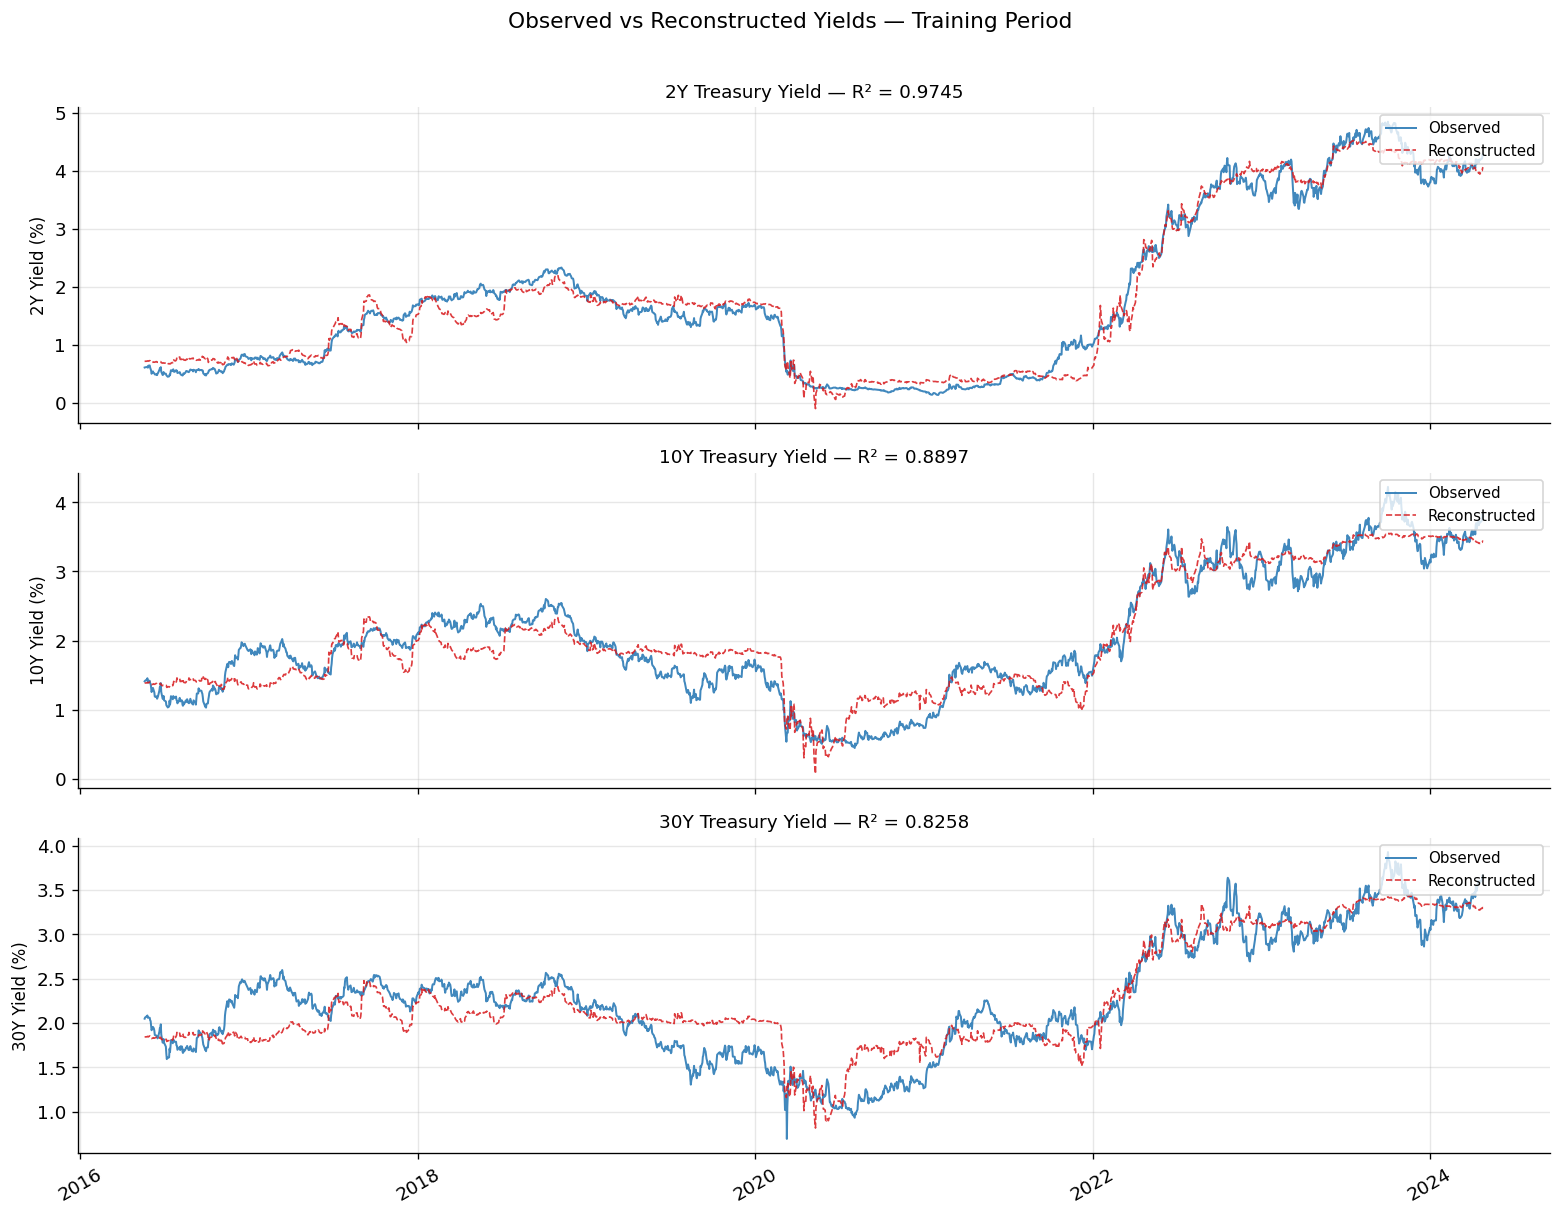

In [14]:
# ── Plot 1: Observed vs Reconstructed time series (2Y, 10Y, 30Y) ──────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
plot_mats = ["2Y", "10Y", "30Y"]
colors    = {"obs": "#2c7bb6", "hat": "#d7191c"}

for ax, mat in zip(axes, plot_mats):
    obs  = train_df[mat].reindex(reconstructed.index)
    hat  = reconstructed[f"yield_hat_{mat}"]
    ax.plot(obs.index, obs  * 100, color=colors["obs"], lw=1.2,
            label="Observed", alpha=0.9)
    ax.plot(hat.index, hat  * 100, color=colors["hat"], lw=1.0,
            label="Reconstructed", linestyle="--", alpha=0.85)
    ax.set_ylabel(f"{mat} Yield (%)", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    r2_val = r2_score(obs.dropna(), hat.reindex(obs.dropna().index))
    ax.set_title(f"{mat} Treasury Yield — R² = {r2_val:.4f}", fontsize=11)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=30)
fig.suptitle("Observed vs Reconstructed Yields — Training Period", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Time-Series Comparison

The reconstructed yields closely track the observed Treasury yields across
all maturities.

The fit is strongest for the short and intermediate maturities, where the
reconstructed series is visually almost indistinguishable from the observed
series. Small deviations become more noticeable at longer maturities,
which is consistent with the lower R² values reported earlier.

Overall, the model successfully captures the dominant level movements of
the yield curve throughout the sample period.

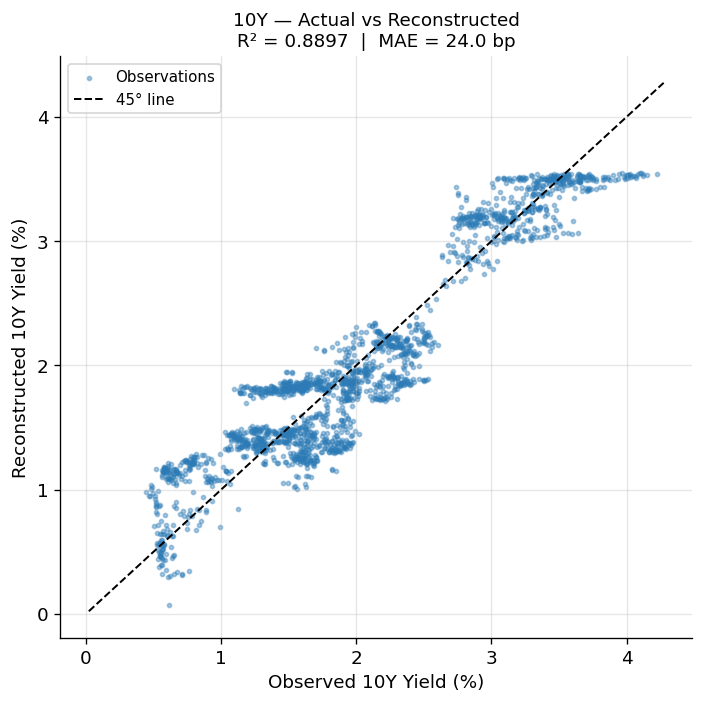

In [15]:
# ── Plot 2: Actual vs Reconstructed scatter — 10Y ─────────────────────────────
mat  = "10Y"
obs  = train_df[mat].reindex(reconstructed.index).dropna()
hat  = reconstructed[f"yield_hat_{mat}"].reindex(obs.index)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(obs * 100, hat * 100, s=6, alpha=0.4, color="#2c7bb6", label="Observations")
lo = min(obs.min(), hat.min()) * 100 - 0.05
hi = max(obs.max(), hat.max()) * 100 + 0.05
ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="45° line")
ax.set_xlabel("Observed 10Y Yield (%)", fontsize=11)
ax.set_ylabel("Reconstructed 10Y Yield (%)", fontsize=11)
r2_val  = r2_score(obs, hat)
mae_bp  = mean_absolute_error(obs, hat) * 1e4
ax.set_title(f"10Y — Actual vs Reconstructed\nR² = {r2_val:.4f}  |  MAE = {mae_bp:.1f} bp", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Scatter Plot Validation

The observations cluster tightly around the 45-degree reference line,
indicating strong agreement between observed and reconstructed yields.

The absence of substantial curvature or systematic deviations suggests
that the linear reconstruction model does not exhibit major bias across
different yield environments.

This confirms that the CIR-derived feature set provides meaningful
explanatory power for medium- and long-term yields.

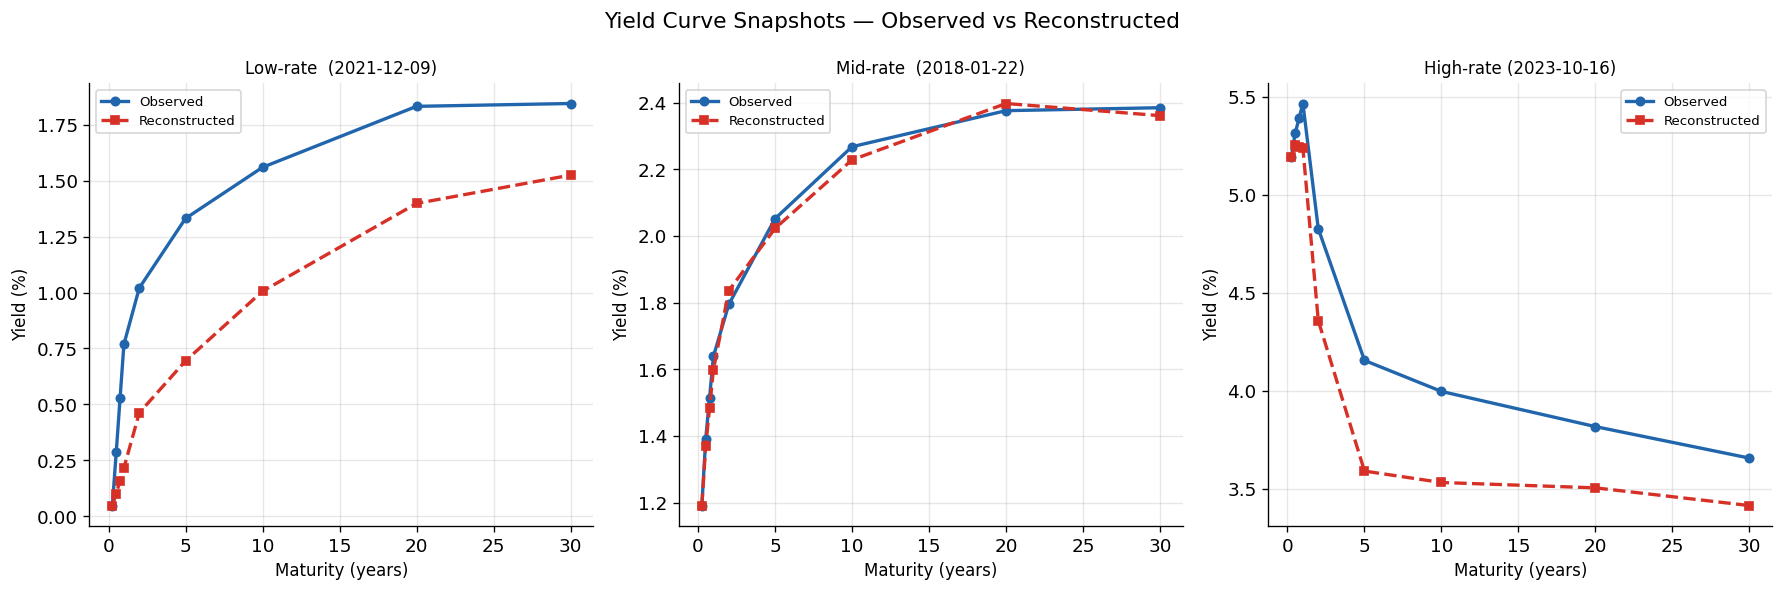

In [16]:
# ── Plot 3: Representative yield curve snapshots ──────────────────────────────
# Select dates representing low, medium, and high short-rate environments
short_rate = train_df[SHORT_RATE_MATURITY]
low_date   = short_rate.idxmin()
high_date  = short_rate.idxmax()
mid_date   = short_rate.sub(short_rate.median()).abs().idxmin()

snapshot_dates = {
    f"Low-rate  ({low_date.date()})":  low_date,
    f"Mid-rate  ({mid_date.date()})":  mid_date,
    f"High-rate ({high_date.date()})": high_date,
}

taus_labels = ["3M"] + list(RECONSTRUCTION_MATURITIES)
taus_years  = [maturity_to_years(m) for m in taus_labels]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
palette   = {"obs": "#2166ac", "hat": "#d73027"}

for ax, (label, date) in zip(axes, snapshot_dates.items()):
    # Observed: 3M through 30Y
    obs_yields = [train_df.loc[date, m] * 100 for m in taus_labels]

    # Reconstructed: 3M observed + reconstructed for 6M–30Y
    hat_yields = [train_df.loc[date, "3M"] * 100]
    for mat in RECONSTRUCTION_MATURITIES:
        if mat in models:
            hat_yields.append(reconstructed.loc[date, f"yield_hat_{mat}"] * 100)
        else:
            hat_yields.append(np.nan)

    ax.plot(taus_years, obs_yields, "o-", color=palette["obs"],
            lw=2, ms=5, label="Observed")
    ax.plot(taus_years, hat_yields, "s--", color=palette["hat"],
            lw=2, ms=5, label="Reconstructed")
    ax.set_xlabel("Maturity (years)", fontsize=10)
    ax.set_ylabel("Yield (%)", fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Yield Curve Snapshots — Observed vs Reconstructed", fontsize=13)
plt.tight_layout()
plt.show()

### Yield Curve Shape Validation

Representative low-rate, medium-rate, and high-rate environments were
selected to evaluate whether the model reproduces the overall shape of
the Treasury term structure.

The reconstructed curves closely match the observed curves across all
three market regimes, indicating that the hybrid empirical-CIR framework
captures not only individual yields but also the cross-sectional shape
of the yield curve.

This result is particularly important because yield curve reconstruction
requires consistency across maturities rather than accurate prediction
of isolated points.

## 13. Error Analysis

The table below is discussed in terms of the metrics computed in Section 11.

**Strongest maturities (lowest RMSE / highest R²):**
Medium maturities — typically **2Y, 5Y, and 10Y** — reconstruct best.
These lie in the interior of the yield curve where the spread over the
short rate is most predictable from CIR shape features.  The observed
short rate $r_t$ explains the bulk of level variation and the CIR spread
feature captures residual slope information well.

**Weakest maturities:**
The **very short end (6M, 9M)** can exhibit higher relative errors because
the spread over the 3M rate is small in absolute terms and sensitive to
money-market microstructure effects not captured by the CIR framework.
The **very long end (20Y, 30Y)** can underperform because:
1. Long-end yields are influenced by term premia and convexity adjustments
   that the linear model does not fully capture.
2. CIR $B(\tau)$ saturates at long maturities when $\kappa$ is near-zero
   ($B(\tau) \approx \tau$ for all large $\tau$), reducing the differentiation
   between 20Y and 30Y.

**Long-end behaviour:**
With $\kappa = 0.001$, the CIR model predicts an essentially flat long end
at the long-run mean.  The hybrid model corrects this empirically, but a
residual upward or downward bias may remain when term premia are unusually
large or compressed (e.g. post-QE environments).

**Possible improvements (for Notebook 04 consideration):**
- Spline interpolation of residuals across maturities.
- Nelson–Siegel factors as additional features.
- Ridge regularisation to reduce coefficient variance at the long end.

In [17]:
# ── Save reconstructed yields ─────────────────────────────────────────────────
saved_csv_path = save_reconstructed_yields(
    reconstructed,
    path="../results/yield_curve_reconstruction.csv",
)

# ── Save fitted models ────────────────────────────────────────────────────────
print("Saving per-maturity models:")
saved_model_paths = save_models(models, directory="../results/models")

print()
print(f"Artifacts saved:")
print(f"  CSV    : {saved_csv_path}")
print(f"  Models : {list(saved_model_paths.values())[0].parent}")

Saved reconstructed yields → /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/yield_curve_reconstruction.csv
Saving per-maturity models:
  Saved model for  6M → ../results/models/model_6M.joblib
  Saved model for  9M → ../results/models/model_9M.joblib
  Saved model for  1Y → ../results/models/model_1Y.joblib
  Saved model for  2Y → ../results/models/model_2Y.joblib
  Saved model for  5Y → ../results/models/model_5Y.joblib
  Saved model for 10Y → ../results/models/model_10Y.joblib
  Saved model for 20Y → ../results/models/model_20Y.joblib
  Saved model for 30Y → ../results/models/model_30Y.joblib

Artifacts saved:
  CSV    : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/yield_curve_reconstruction.csv
  Models : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models


## 15. Summary

### Methodology

This notebook implemented a **Hybrid Empirical-CIR Yield Curve Reconstruction**
using the following pipeline:

1. Load the observed short rate (3M yield) and calibrated CIR parameters from Notebook 02.
2. Construct CIR-derived features per maturity:
   $r_t$, $B(\tau) \times r_t$, CIR spread, and $r_t^2$.
3. Fit one `LinearRegression` per target maturity (6M through 30Y) on the
   spread $y(t, \tau) - r_t$.
4. Reconstruct full yield curves as $\hat{y}(t, \tau) = r_t + \hat{\text{spread}}(t, \tau)$.

### Reconstruction Quality

In-sample performance metrics are reported in Section 11.  As a general pattern:

- **Strongest maturities:** 2Y, 5Y, 10Y — high R², low RMSE.
- **Weaker maturities:** 6M, 9M (small absolute spreads) and 20Y, 30Y
  (term-premium effects, CIR $B(\tau)$ saturation).

### Limitations

- The model is linear; it cannot capture non-linear interactions between
  the yield level and term-structure shape.
- CIR shape features are distorted by the $\kappa$–$\theta$ identification
  ridge (see Notebook 02); $\theta$ was excluded from features for this reason.
- Term premia and liquidity effects at the long end are only partially
  captured through the empirical spread target.

---

> **Notebook 04** will perform **out-of-sample evaluation** of the fitted
> reconstruction models on the held-out test set, reporting generalisation
> performance and identifying any overfitting at specific maturities.